# Minimal Gamma Spectra: Raw + Background-Subtracted

This notebook contains only the requested minimal functionality:
- ASC file reading
- Background subtraction (time-normalized)
- Linear calibration from user-provided ROI channel positions
- Plot raw and background-subtracted spectra for Cs, Co, and Unknown
- Annotate unknown fixed channels and print their energies in MeV

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [3]:
def read_asc_spectrum(path):
    p = Path(path)
    text = p.read_text(encoding='utf-8', errors='ignore')
    channels = []
    counts = []
    for line in text.splitlines():
        m = re.match(r'^\s*(\d+)\s*,\s*(\d+)\s*,', line)
        if m:
            channels.append(int(m.group(1)))
            counts.append(int(m.group(2)))
    if not channels:
        raise ValueError(f'No channel/count lines found in {path}')
    return {'path': str(p), 'channels': np.array(channels, dtype=float), 'counts': np.array(counts, dtype=float)}

In [4]:
def subtract_background(source_spectrum, background_spectrum, scale_bg=1.0):
    src_ch = source_spectrum['channels']
    src_ct = source_spectrum['counts']
    bg_ct = background_spectrum['counts']
    out_channels = src_ch.copy()
    out_counts = np.zeros_like(out_channels)
    for i, ch in enumerate(out_channels):
        idx = int(np.round(ch))
        if 0 <= idx < len(src_ct) and 0 <= idx < len(bg_ct):
            src_val = src_ct[i]
            bg_val = scale_bg * bg_ct[idx]
            out_counts[i] = max(0, src_val - bg_val)
        else:
            out_counts[i] = max(0, src_ct[i] - scale_bg * bg_ct[i])
    return {'path': f"{source_spectrum['path']} (bg-subtracted)", 'channels': out_channels, 'counts': out_counts}

In [5]:
def fit_linear_calibration(cal_points):
    x = np.array([p['channel'] for p in cal_points], dtype=float)
    y = np.array([p['energy_mev'] for p in cal_points], dtype=float)
    sx = np.array([p.get('sigma_channel', 0.0) for p in cal_points], dtype=float)
    if len(x) < 2:
        raise ValueError('At least 2 calibration points are required')
    coeffs, cov = np.polyfit(x, y, 1, cov=True)
    slope, intercept = float(coeffs[0]), float(coeffs[1])
    slope_unc = float(np.sqrt(cov[0,0])) if cov is not None else 0.0
    intercept_unc = float(np.sqrt(cov[1,1])) if cov is not None else 0.0
    return {
        'slope': slope,
        'intercept': intercept,
        'slope_unc': slope_unc,
        'intercept_unc': intercept_unc,
    }

def channel_to_mev(channel, calibration):
    return calibration['slope'] * np.asarray(channel) + calibration['intercept']

In [6]:
# Files (expected to be in the same folder)
CESIO_FILE = 'CESIOCAL.ASC'
COBAL_FILE = 'COBALCAL.ASC'
BACKGROUND_FILE = 'BACKGROUND.ASC'
UNKNOWN_FILE = 'CDAY1RED.ASC'

# Acquisition times (seconds) - adjust if needed
ACQ = {'background': 2106.0, 'cesium': 247.0, 'cobalt': 1645.0, 'unknown': 1679.0}

In [7]:
# Read raw spectra
cesio_raw = read_asc_spectrum(CESIO_FILE)
cobal_raw = read_asc_spectrum(COBAL_FILE)
background = read_asc_spectrum(BACKGROUND_FILE)
unknown_raw = read_asc_spectrum(UNKNOWN_FILE)

print('Loaded spectra:')
print(cesio_raw['path'], 'channels=', len(cesio_raw['channels']))
print(cobal_raw['path'], 'channels=', len(cobal_raw['channels']))
print(background['path'], 'channels=', len(background['channels']))
print(unknown_raw['path'], 'channels=', len(unknown_raw['channels']))

Loaded spectra:
CESIOCAL.ASC channels= 1024
COBALCAL.ASC channels= 1024
BACKGROUND.ASC channels= 1024
CDAY1RED.ASC channels= 1024


In [8]:
# Background subtraction (time-normalized)
cesio = subtract_background(cesio_raw, background, scale_bg=ACQ['cesium']/ACQ['background'])
cobal = subtract_background(cobal_raw, background, scale_bg=ACQ['cobalt']/ACQ['background'])
unknown = subtract_background(unknown_raw, background, scale_bg=ACQ['unknown']/ACQ['background'])

print('Background subtraction done. Total counts (raw -> bg-sub):')
print('Cs: ', np.sum(cesio_raw['counts']), '->', np.sum(cesio['counts']))
print('Co: ', np.sum(cobal_raw['counts']), '->', np.sum(cobal['counts']))
print('Unknown: ', np.sum(unknown_raw['counts']), '->', np.sum(unknown['counts']))

Background subtraction done. Total counts (raw -> bg-sub):
Cs:  639411.0 -> 618782.6913580247
Co:  313393.0 -> 174892.86752136753
Unknown:  1542143.0 -> 1400718.2905982905


In [9]:
# Calibration points provided (channels -> energy in MeV)
# Include sigma_channel derived from FWHM (sigma = FWHM / 2.355)
CALIBRATION_POINTS = [
    {'label':'Cs-137 661.7 keV','energy_mev':0.6617,'channel':386.01,'fwhm':24.46,'sigma_channel':24.46/2.355},
    {'label':'Cs-137 32 keV','energy_mev':0.0320,'channel':20.29,'fwhm':3.30,'sigma_channel':3.30/2.355},
    {'label':'Cs-137 184 keV','energy_mev':0.1840,'channel':116.69,'fwhm':14.10,'sigma_channel':14.10/2.355},
    {'label':'Co-60 backscatter 214 keV','energy_mev':0.2140,'channel':57.82,'fwhm':43.35,'sigma_channel':43.35/2.355},
    {'label':'Co-60 1173 keV','energy_mev':1.1732,'channel':672.14,'fwhm':26.25,'sigma_channel':26.25/2.355},
    {'label':'Co-60 1332 keV','energy_mev':1.3325,'channel':762.37,'fwhm':33.92,'sigma_channel':33.92/2.355},
]
cal = fit_linear_calibration(CALIBRATION_POINTS)
print('Calibration regression: E(MeV) = slope * channel + intercept')
print(f"slope = {cal['slope']:.9e} ± {cal['slope_unc']:.9e}")
print(f"intercept = {cal['intercept']:.9e} ± {cal['intercept_unc']:.9e}")

x_cal = np.array([p['channel'] for p in CALIBRATION_POINTS], dtype=float)
y_cal = np.array([p['energy_mev'] for p in CALIBRATION_POINTS], dtype=float)
sx_cal = np.array([p['sigma_channel'] for p in CALIBRATION_POINTS], dtype=float)
y_fit = channel_to_mev(x_cal, cal)

Calibration regression: E(MeV) = slope * channel + intercept
slope = 1.695921011e-03 ± 7.252700093e-05
intercept = 2.992941123e-02 ± 3.242634694e-02


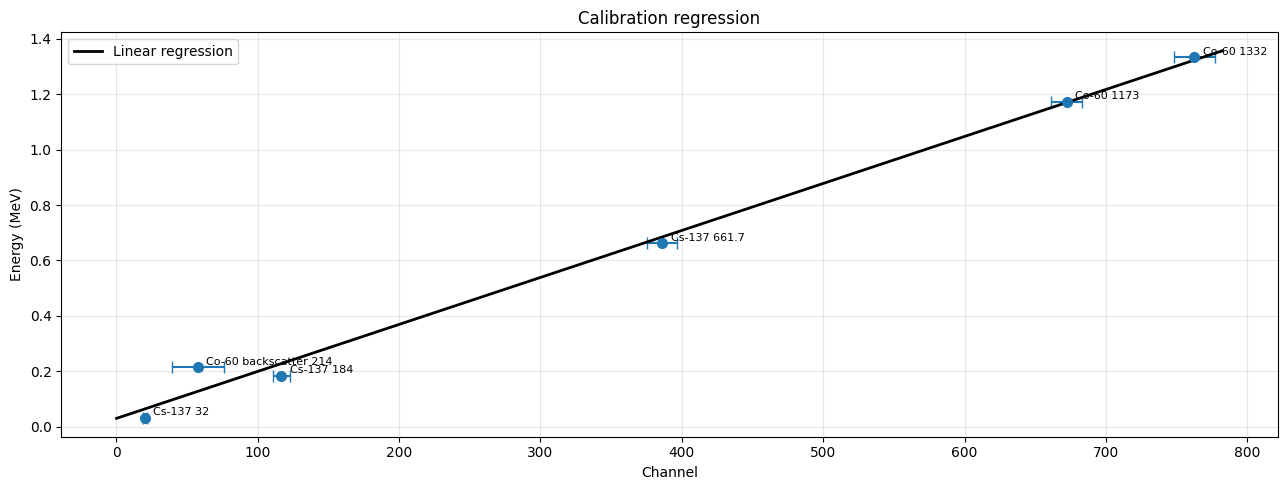

In [17]:
# Calibration regression plot
fig = plt.subplots(1, 1, figsize=(13, 5))

x_line = np.linspace(x_cal.min() - 20, x_cal.max() + 20, 200)
y_line = channel_to_mev(x_line, cal)

for point in CALIBRATION_POINTS:
    plt.errorbar(
        point['channel'],
        point['energy_mev'],
        xerr=point['sigma_channel'],
        fmt='o',
        ms=7,
        capsize=4,
        color='tab:blue',
        ecolor='tab:blue',
    )
    plt.text(point['channel'] + 6, point['energy_mev'] + 0.01, point['label'].replace(' keV', ''), fontsize=8)

plt.plot(x_line, y_line, color='black', lw=2, label='Linear regression')
plt.xlabel('Channel')
plt.ylabel('Energy (MeV)')
plt.title('Calibration regression')
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

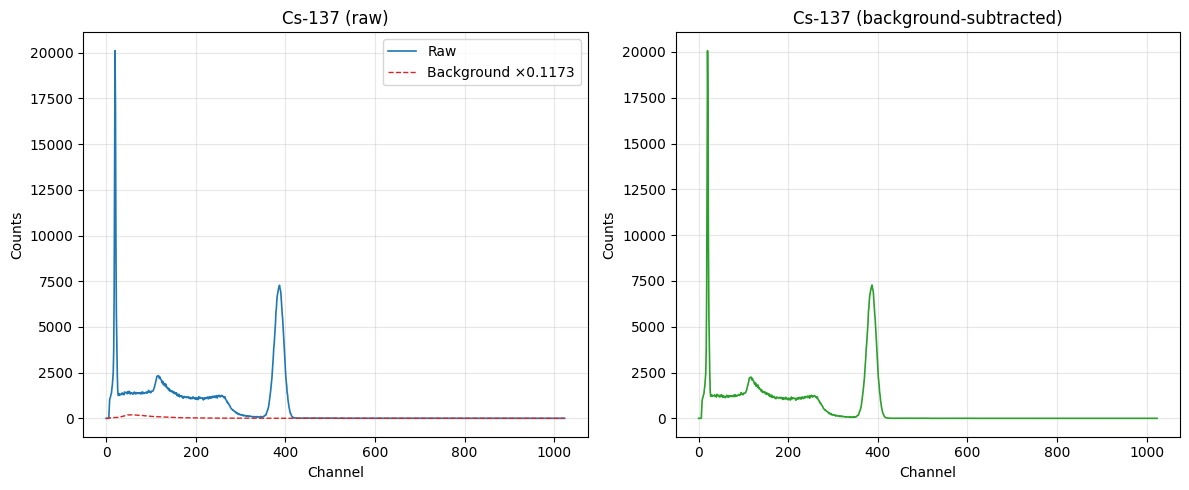

In [11]:
# Cs-137: raw + background overlay | background-subtracted
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
scale_cs = ACQ['cesium'] / ACQ['background']

axs[0].plot(cesio_raw['channels'], cesio_raw['counts'], color='tab:blue', lw=1.2, label='Raw')
axs[0].plot(background['channels'], scale_cs * background['counts'], color='tab:red', lw=1, linestyle='--', label=f'Background ×{scale_cs:.4f}')
axs[0].set_title('Cs-137 (raw)')
axs[0].set_xlabel('Channel')
axs[0].set_ylabel('Counts')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].plot(cesio['channels'], cesio['counts'], color='tab:green', lw=1.2)
axs[1].set_title('Cs-137 (background-subtracted)')
axs[1].set_xlabel('Channel')
axs[1].set_ylabel('Counts')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

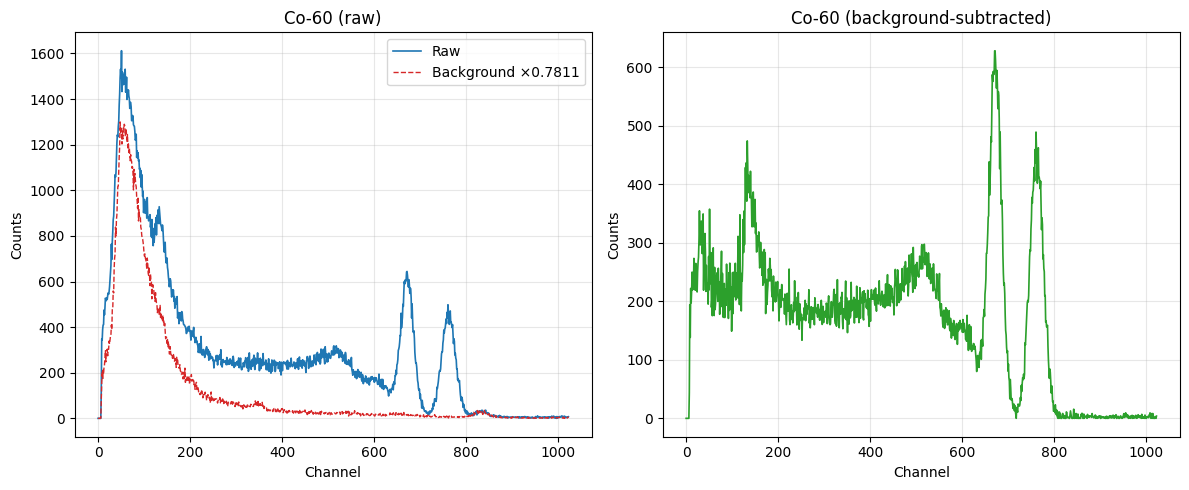

In [12]:
# Co-60: raw + background overlay | background-subtracted
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
scale_co = ACQ['cobalt'] / ACQ['background']

axs[0].plot(cobal_raw['channels'], cobal_raw['counts'], color='tab:blue', lw=1.2, label='Raw')
axs[0].plot(background['channels'], scale_co * background['counts'], color='tab:red', lw=1, linestyle='--', label=f'Background ×{scale_co:.4f}')
axs[0].set_title('Co-60 (raw)')
axs[0].set_xlabel('Channel')
axs[0].set_ylabel('Counts')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].plot(cobal['channels'], cobal['counts'], color='tab:green', lw=1.2)
axs[1].set_title('Co-60 (background-subtracted)')
axs[1].set_xlabel('Channel')
axs[1].set_ylabel('Counts')
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


Unknown fixed channels -> MeV:
  Channel  449.82 -> 0.792789 MeV
  Channel  554.95 -> 0.971081 MeV
  Channel  807.10 -> 1.398707 MeV
  Channel  631.84 -> 1.101480 MeV
  Channel  203.21 -> 0.374558 MeV
  Channel  145.83 -> 0.277246 MeV
  Channel   75.58 -> 0.158107 MeV
  Channel   54.72 -> 0.122730 MeV
  Channel   25.48 -> 0.073141 MeV


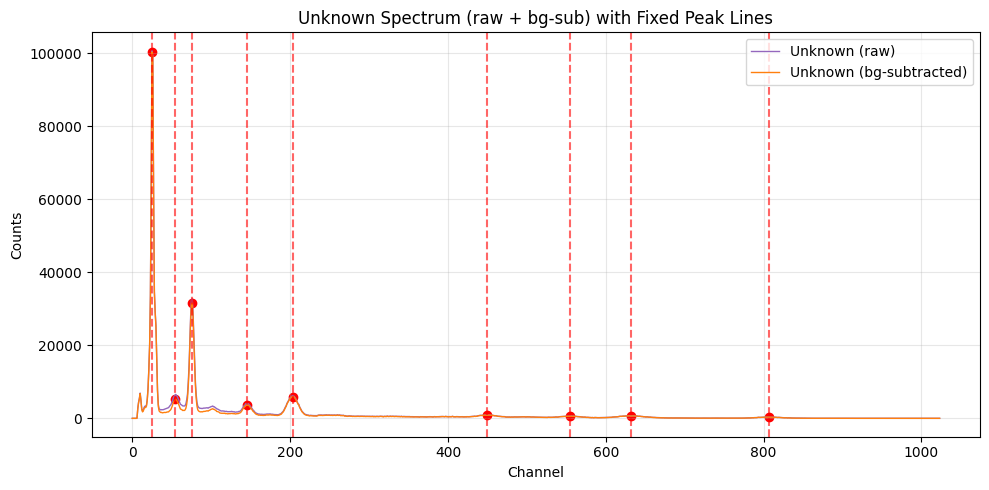

In [13]:
# Unknown: raw + background overlay | background-subtracted, with fixed channels only
unknown_fixed_channels = [449.82, 554.95, 807.10, 631.84, 203.21, 145.83, 75.58, 54.72, 25.48]
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(unknown_raw['channels'], unknown_raw['counts'], lw=1, label='Unknown (raw)', color='tab:purple')
ax.plot(unknown['channels'], unknown['counts'], lw=1, label='Unknown (bg-subtracted)', color='tab:orange')
for ch in unknown_fixed_channels:
    idx = int(round(ch))
    idx = max(0, min(idx, len(unknown['channels'])-1))
    cnt = unknown['counts'][idx]
    ax.axvline(ch, color='red', linestyle='--', alpha=0.6)
    ax.scatter(ch, cnt, color='red')
print('\nUnknown fixed channels -> MeV:')
for ch in unknown_fixed_channels:
    energy = float(channel_to_mev(ch, cal))
    print(f"  Channel {ch:7.2f} -> {energy:.6f} MeV")
ax.set_xlabel('Channel')
ax.set_ylabel('Counts')
ax.set_title('Unknown Spectrum (raw + bg-sub) with Fixed Peak Lines')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()